In [2]:
!pip install rioxarray geopandas cftime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.1 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Mencoba membuka file: /kaggle/input/datasets/jerismeteo/chirps-kebumen/data/CHIRPS/2026/2026_01/chirps-v3.0.rnl.2026.01.01.nc


/tmp/ipykernel_57/2865974487.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


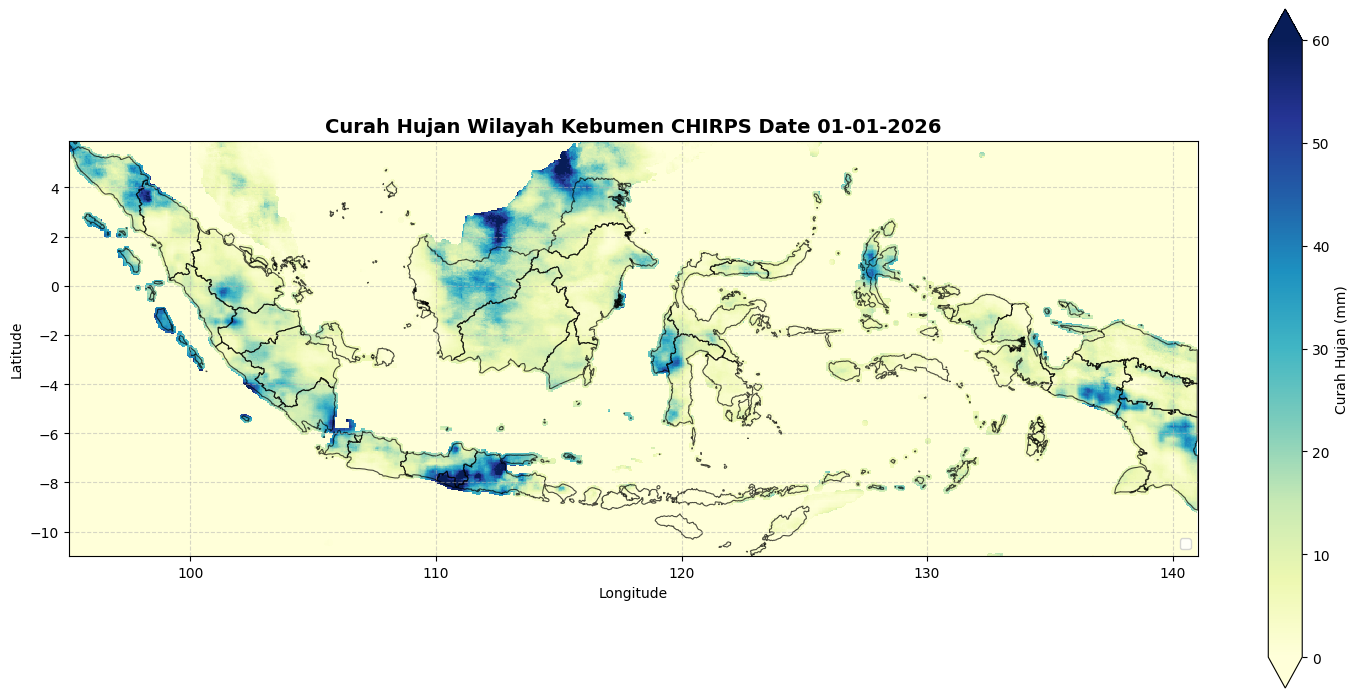

In [3]:
import os
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PERSIAPAN DATA (GEOJSON & NETCDF)
# ==========================================
year = 2026
month = 1
day = 1

# Melacak lokasi folder tempat script ini dijalankan
cwd = os.getcwd()
BASE_DIR = "/kaggle" if "/kaggle/" in cwd or cwd == "/kaggle" else cwd

# Menentukan lokasi GeoJSON
file_geojson = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "projek-downscale", "Indonesia.geojson"
)

# --- PERBAIKAN DIREKTORI DI SINI ---
# Mengikuti pola: .../CHIRPS/2007/chirps-v3.0.rnl.2007.01.01.nc
file_nc = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "chirps-kebumen", "data", "CHIRPS", 
    f"{year}", f"{year}_{month:02d}", f"chirps-v3.0.rnl.{year}.{month:02d}.{day:02d}.nc"
)

print(f"Mencoba membuka file: {file_nc}")

# Pastikan file ada sebelum dibuka
if not os.path.exists(file_nc):
    print(f"⚠️ ERROR: File tidak ditemukan di {file_nc}")
else:
    gdf = gpd.read_file(file_geojson)

    # Buka file NetCDF
    da_global = rioxarray.open_rasterio(file_nc, masked=True).squeeze()

    # Safety Check: Pastikan NetCDF terbaca CRS-nya.
    if da_global.rio.crs is None:
        da_global.rio.write_crs("EPSG:4326", inplace=True)

    # ==========================================
    # 2. PENYELARASAN CRS
    # ==========================================
    if gdf.crs != da_global.rio.crs:
        gdf = gdf.to_crs(da_global.rio.crs)

    # ==========================================
    # 3. CLIPPING (Bounding Box)
    # ==========================================
    batas_kiri, batas_bawah, batas_kanan, batas_atas = gdf.total_bounds
    da_kebumen = da_global.rio.clip_box(
        minx=batas_kiri, miny=batas_bawah, maxx=batas_kanan, maxy=batas_atas
    )

    # ==========================================
    # 4. VISUALISASI
    # ==========================================
    fig, ax = plt.subplots(figsize=(15, 10))

    # Plot Raster CHIRPS
    da_kebumen.plot(
        ax=ax, 
        cmap='YlGnBu', 
        vmax=60,
        vmin=0, 
        cbar_kwargs={'label': 'Curah Hujan (mm)', 'shrink': 0.7}
    )

    # Plot Garis Tepi GeoJSON
    gdf.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=0.8, alpha=0.7)

    # Kunci Ukuran Kanvas
    ax.set_xlim(batas_kiri, batas_kanan)
    ax.set_ylim(batas_bawah, batas_atas)

    title = f'Curah Hujan Wilayah Kebumen CHIRPS Date {day:02d}-{month:02d}-{year}'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

Mencoba membuka file: /kaggle/input/datasets/jerismeteo/chirps-kebumen/data/CHIRPS/2026/2026_01/chirps-v3.0.rnl.2026.01.01.nc


/tmp/ipykernel_57/718282905.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


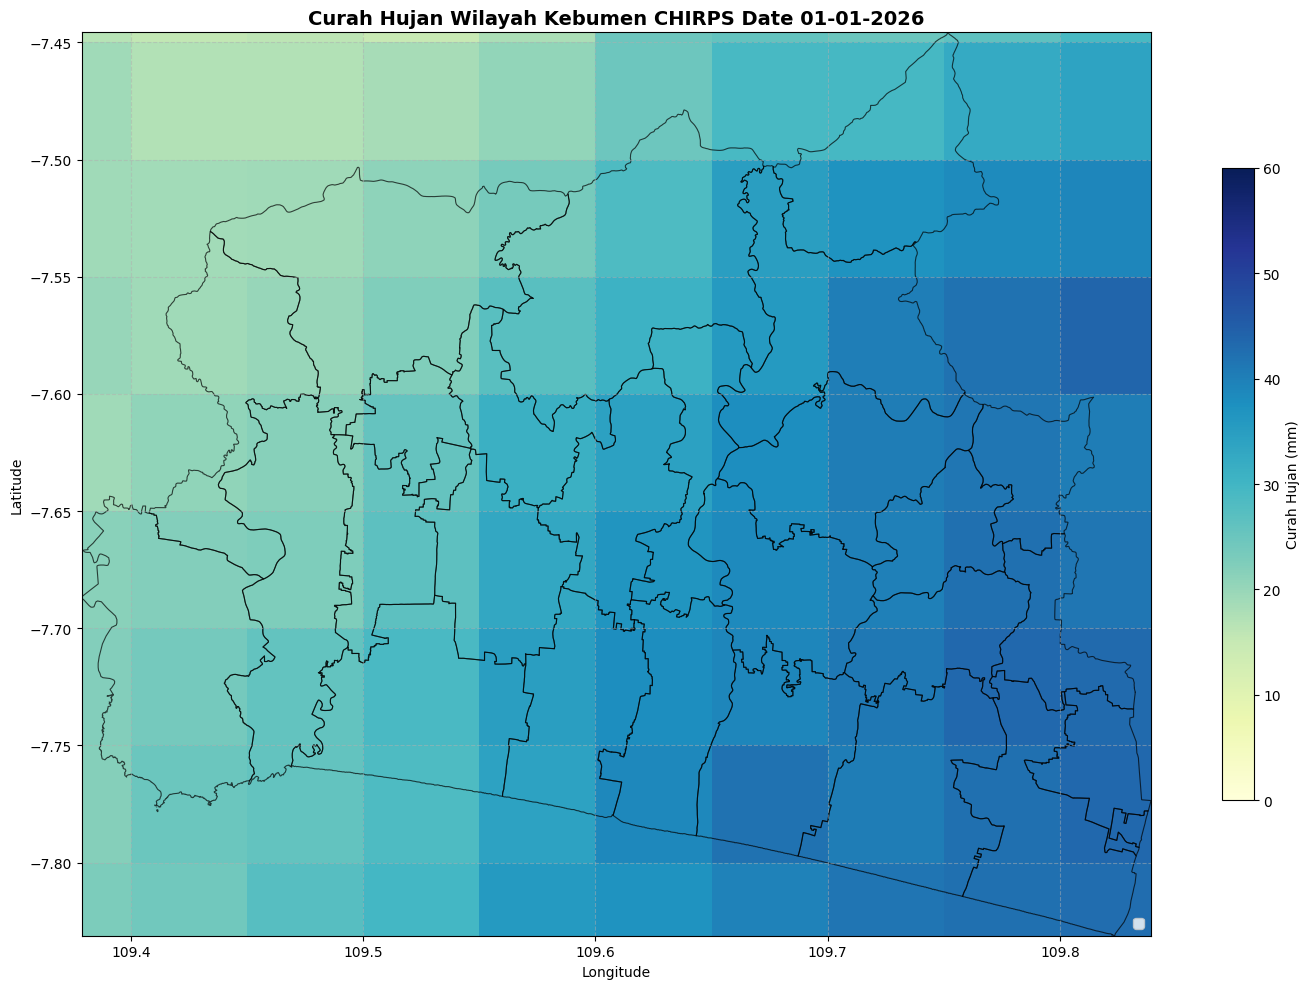

In [4]:
import os
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PERSIAPAN DATA (GEOJSON & NETCDF)
# ==========================================
year = 2026
month = 1
day = 1

# Melacak lokasi folder tempat script ini dijalankan
cwd = os.getcwd()
BASE_DIR = "/kaggle" if "/kaggle/" in cwd or cwd == "/kaggle" else cwd

# Menentukan lokasi GeoJSON
file_geojson = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "projek-downscale", "33.05_kecamatan.geojson"
)

# --- PERBAIKAN DIREKTORI DI SINI ---
# Mengikuti pola: .../CHIRPS/2007/chirps-v3.0.rnl.2007.01.01.nc
file_nc = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "chirps-kebumen", "data", "CHIRPS", 
    f"{year}", f"{year}_{month:02d}", f"chirps-v3.0.rnl.{year}.{month:02d}.{day:02d}.nc"
)

print(f"Mencoba membuka file: {file_nc}")

# Pastikan file ada sebelum dibuka
if not os.path.exists(file_nc):
    print(f"⚠️ ERROR: File tidak ditemukan di {file_nc}")
else:
    gdf = gpd.read_file(file_geojson)

    # Buka file NetCDF
    da_global = rioxarray.open_rasterio(file_nc, masked=True).squeeze()

    # Safety Check: Pastikan NetCDF terbaca CRS-nya.
    if da_global.rio.crs is None:
        da_global.rio.write_crs("EPSG:4326", inplace=True)

    # ==========================================
    # 2. PENYELARASAN CRS
    # ==========================================
    if gdf.crs != da_global.rio.crs:
        gdf = gdf.to_crs(da_global.rio.crs)

    # ==========================================
    # 3. CLIPPING (Bounding Box)
    # ==========================================
    batas_kiri, batas_bawah, batas_kanan, batas_atas = gdf.total_bounds
    da_kebumen = da_global.rio.clip_box(
        minx=batas_kiri, miny=batas_bawah, maxx=batas_kanan, maxy=batas_atas
    )

    # ==========================================
    # 4. VISUALISASI
    # ==========================================
    fig, ax = plt.subplots(figsize=(15, 10))

    # Plot Raster CHIRPS
    da_kebumen.plot(
        ax=ax, 
        cmap='YlGnBu', 
        vmax=60,
        vmin=0, 
        cbar_kwargs={'label': 'Curah Hujan (mm)', 'shrink': 0.7}
    )

    # Plot Garis Tepi GeoJSON
    gdf.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=0.8, alpha=0.7)

    # Kunci Ukuran Kanvas
    ax.set_xlim(batas_kiri, batas_kanan)
    ax.set_ylim(batas_bawah, batas_atas)

    title = f'Curah Hujan Wilayah Kebumen CHIRPS Date {day:02d}-{month:02d}-{year}'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

Mencari data di: /kaggle/input/datasets/jerismeteo/chirps-kebumen/data/CHIRPS/2014/2014_01/chirps-v3.0.rnl.2014.01.*.nc
Ditemukan 31 file NetCDF untuk Bulan 01 Tahun 2014.
Memulai proses ekstraksi dan pemotongan data...
Mengakumulasi curah hujan selama satu bulan...


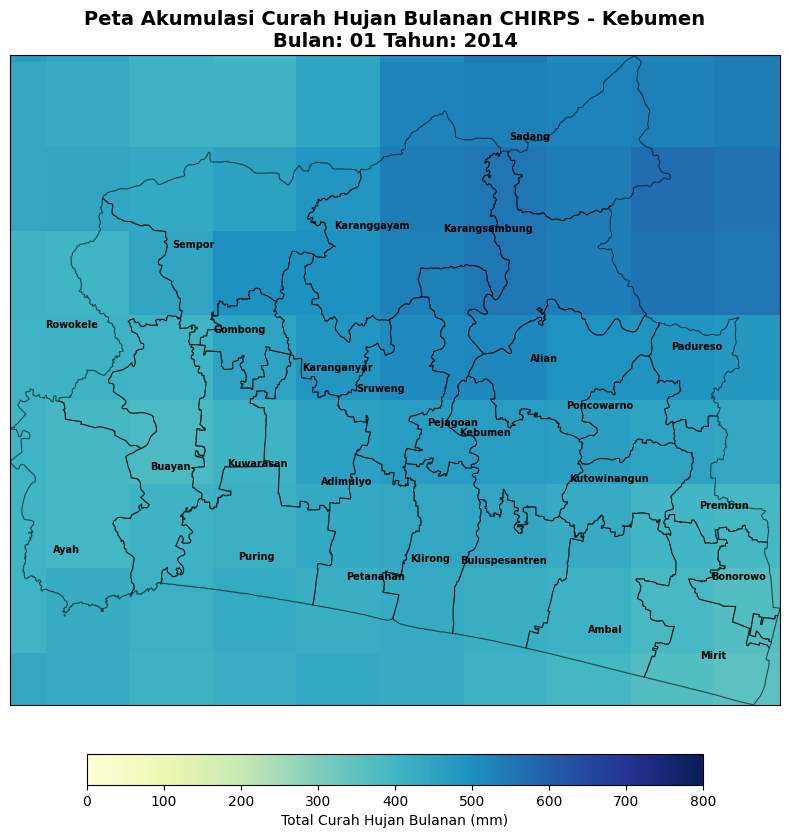

Selesai! Peta berhasil di-render dan disimpan sebagai Akumulasi_CHIRPS_Kebumen_2014_01.nc


In [5]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
import os

# ==========================================
# 1. PARAMETER WAKTU & LOKASI
# ==========================================
year = 2014  # Sesuaikan dengan tahun data Anda
month = 1    # Sesuaikan dengan bulan data Anda

# Melacak lokasi folder tempat script ini dijalankan
cwd = os.getcwd()
BASE_DIR = "/kaggle" if "/kaggle/" in cwd or cwd == "/kaggle" else cwd

# Menentukan lokasi GeoJSON (Asumsi berada di folder dataset Kaggle)
file_geojson = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "projek-downscale", "33.05_kecamatan.geojson"
)

# --- PERBAIKAN DIREKTORI (Hanya merujuk ke foldernya saja) ---
folder_chirps = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "chirps-kebumen", "data", "CHIRPS", 
    f"{year}", f"{year}_{month:02d}"
)

# Buka GeoJSON dan ambil Bounding Box (Kotak Batas)
gdf = gpd.read_file(file_geojson)
batas_kiri, batas_bawah, batas_kanan, batas_atas = gdf.total_bounds

# ==========================================
# 2. MENCARI SEMUA FILE DI BULAN TERSEBUT
# ==========================================
# --- PERBAIKAN POLA PENCARIAN (Menyesuaikan dengan nama file NetCDF baru) ---
pola_pencarian = os.path.join(folder_chirps, f"chirps-v3.0.rnl.{year}.{month:02d}.*.nc")
daftar_file = glob.glob(pola_pencarian)
daftar_file.sort() # Pastikan urutan harinya benar dari tanggal 1 sampai akhir bulan

print(f"Mencari data di: {pola_pencarian}")
print(f"Ditemukan {len(daftar_file)} file NetCDF untuk Bulan {month:02d} Tahun {year}.")

if len(daftar_file) == 0:
    print("⚠️ Peringatan: Tidak ada file yang ditemukan. Pastikan path direktori sudah benar!")
else:
    # ==========================================
    # 3. LOOPING: MEMBACA DAN MEMOTONG PER HARI
    # ==========================================
    print("Memulai proses ekstraksi dan pemotongan data...")
    data_harian_terpotong = []

    # Kita buka file global, potong ke Kebumen, lalu simpan potongan kecilnya saja ke RAM
    for file in daftar_file:
        da_hari_ini = rioxarray.open_rasterio(file, masked=True).squeeze()
        
        # Safety Check: Paksakan CRS ke WGS84 jika NetCDF kehilangan atribut spasialnya
        if da_hari_ini.rio.crs is None:
            da_hari_ini.rio.write_crs("EPSG:4326", inplace=True)
        
        # Samakan CRS jika GeoJSON berbeda dengan data raster
        if file == daftar_file[0] and gdf.crs != da_hari_ini.rio.crs:
            gdf = gdf.to_crs(da_hari_ini.rio.crs)
        
        # Potong menggunakan clip_box
        da_potongan = da_hari_ini.rio.clip_box(
            minx=batas_kiri, miny=batas_bawah, maxx=batas_kanan, maxy=batas_atas
        )
        
        # Masukkan hasil potongan ke dalam list (keranjang)
        data_harian_terpotong.append(da_potongan)
        
        # Tutup file global untuk membebaskan memori
        da_hari_ini.close()

    # ==========================================
    # 4. PROSES AKUMULASI (PENJUMLAHAN BULANAN)
    # ==========================================
    print("Mengakumulasi curah hujan selama satu bulan...")
    # Gabungkan potongan harian menjadi satu dimensi 'time'
    da_gabungan = xr.concat(data_harian_terpotong, dim='time')

    # Jumlahkan dari atas ke bawah (menembus dimensi waktu)
    da_akumulasi_bulanan = da_gabungan.sum(dim='time', skipna=True)

    # ==========================================
    # 5. VISUALISASI PETA AKUMULASI
    # ==========================================
    fig, ax = plt.subplots(figsize=(8, 10))

    # Plot Raster Akumulasi CHIRPS
    da_akumulasi_bulanan.plot(
        ax=ax, 
        cmap='YlGnBu', 
        vmin=0, 
        vmax=800, # Batas diturunkan sedikit ke 600 agar gradasi warna lebih terlihat
        cbar_kwargs={
            'label': 'Total Curah Hujan Bulanan (mm)', 
            'orientation': 'horizontal', 
            'pad': 0.05, 
            'shrink': 0.8
        }
    )

    # Plot Garis Tepi GeoJSON 
    gdf.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=0.8, alpha=0.6)

# Plot Label Kecamatan (Telah disesuaikan mendekati titik Kantor Kecamatan / Pusat Kota)
    koordinat_kecamatan = {
        'Adimulyo': (109.5804, -7.6987), 
        'Alian': (109.6979, -7.6256),
        'Ambal': (109.7345, -7.7865), 
        'Ayah': (109.4124, -7.7391),
        'Bonorowo': (109.8142, -7.7551), 
        'Buayan': (109.4746, -7.6895),
        'Buluspesantren': (109.6738, -7.7456), 
        'Gombong': (109.5161, -7.6083),
        'Karanganyar': (109.5744, -7.6309), 
        'Karanggayam': (109.5951, -7.5469),
        'Karangsambung': (109.6644, -7.5484), 
        'Kebumen': (109.6631, -7.6698),
        'Klirong': (109.6301, -7.7441), 
        'Kutowinangun': (109.7369, -7.6966),
        'Kuwarasan': (109.5268, -7.6881), 
        'Mirit': (109.7994, -7.8016),
        'Padureso': (109.7892, -7.6186), 
        'Pejagoan': (109.6437, -7.6634),
        'Petanahan': (109.5971, -7.7548), 
        'Poncowarno': (109.7313, -7.6536),
        'Prembun': (109.8055, -7.7126), 
        'Puring': (109.5264, -7.7431),
        'Rowokele': (109.4158, -7.6053), 
        'Sadang': (109.6896, -7.4938),
        'Sempor': (109.4883, -7.5581), 
        'Sruweng': (109.6006, -7.6433)
    }
    for nama_kec, (lon, lat) in koordinat_kecamatan.items():
        ax.text(
            lon, lat, nama_kec, 
            fontsize=7, 
            ha='center', va='center', 
            color='black', 
            fontweight='bold',
        )

    # Kunci Ukuran Kanvas
    ax.set_xlim(batas_kiri, batas_kanan)
    ax.set_ylim(batas_bawah, batas_atas)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

    title = f'Peta Akumulasi Curah Hujan Bulanan CHIRPS - Kebumen\nBulan: {month:02d} Tahun: {year}'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Menyimpan hasil akumulasi menjadi file NetCDF (bukan TIF, agar waktu dan metadata aman)
    output_filename = f"Akumulasi_CHIRPS_Kebumen_{year}_{month:02d}.nc"
    da_akumulasi_bulanan.to_netcdf(output_filename)
    print(f"Selesai! Peta berhasil di-render dan disimpan sebagai {output_filename}")

In [6]:
import xarray as xr
import rioxarray
import pandas as pd
import glob
import os

# 1. TENTUKAN KOORDINAT TARGET (Misal: Pusat Kabupaten Kebumen)
# Pastikan koordinat ini sesuai dengan Sistem Koordinat (CRS) file Anda
lat_target = -7.668
lon_target = 109.651
tahun_target = 2026

# 2. DAFTAR SEMUA FILE TIFF
# Ganti dengan path folder tempat Anda menyimpan hasil download
path_folder = r"D:\Kuliah Semester 7\SKRIPSI\CHIRPS_" + str(tahun_target)
semua_file = glob.glob(os.path.join(path_folder, "*.tif"))
semua_file.sort() # Penting agar urutan waktunya benar

print(f"Ditemukan {len(semua_file)} file. Memulai proses penggabungan...")

# 3. BUKA SEMUA FILE SEBAGAI SATU DATASET (Multi-File Dataset)
# Kita tambahkan dimensi baru bernama 'time' untuk setiap file
def pre_process(ds):
    # Mengambil tanggal dari nama file (Asumsi format nama file CHIRPS mengandung tanggal)
    # Contoh: chirps-v3.0.rnl.2025.01.01.tif
    # Jika nama file tidak mengandung tanggal, Anda harus menyesuaikan bagian ini
    nama_file = ds.encoding['source']
    tanggal_str = os.path.basename(nama_file).split('.')[3:6] # Ambil 2025, 01, 01
    tanggal = pd.to_datetime("-".join(tanggal_str))
    
    return ds.expand_dims(time=[tanggal])

# Gunakan open_mfdataset untuk performa tinggi
ds_combined = xr.open_mfdataset(semua_file, preprocess=pre_process, engine="rasterio")

# 4. EKSTRAKSI SATU PIXEL (POINT EXTRACTION)
# method="nearest" digunakan jika koordinat tidak pas persis di tengah piksel
print(f"Mengekstrak data di koordinat: {lat_target}, {lon_target}")
point_data = ds_combined.sel(x=lon_target, y=lat_target, method="nearest")

# 5. KONVERSI KE PANDAS DATAFRAME & SIMPAN KE CSV
# Ubah ke DataFrame TANPA menggunakan argumen name
df_hasil = point_data.to_dataframe().reset_index()

# Catatan: Secara default, rioxarray (pembaca TIFF) menamai kolom datanya dengan 'band_data'
# Kita ubah nama kolom 'band_data' tersebut menjadi 'curah_hujan'
df_hasil = df_hasil.rename(columns={'band_data': 'curah_hujan'})

# Memilih kolom yang penting saja (membuang kolom x, y, band, spatial_ref yang tidak perlu)
# Gunakan try-except ringan untuk memastikan jika nama variabel bawaannya berbeda
try:
    df_hasil = df_hasil[['time', 'curah_hujan']]
except KeyError:
    # Jika error, berarti nama variabel bawaan TIFF-nya bukan 'band_data'.
    # Kita ambil kolom pertama dan terakhir (waktu dan nilai) secara otomatis.
    kolom_nilai = df_hasil.columns[-1]
    df_hasil = df_hasil.rename(columns={kolom_nilai: 'curah_hujan'})
    df_hasil = df_hasil[['time', 'curah_hujan']]

# Simpan ke CSV
nama_csv = f"timeseries_hujan_kebumen_{tahun_target}.csv"
df_hasil.to_csv(nama_csv, index=False)

print(f"🎉 Selesai! Data tersimpan di {nama_csv}")
print(df_hasil.head())

Ditemukan 0 file. Memulai proses penggabungan...


OSError: no files to open